# Recommender Systems - Individual Assignment - Movielens

## Objective
Design and implement a prototype of a movie recommender system using the MovieLens dataset by exploring various recommendation techniques and evaluating them.


## Data Exploration

In [1]:
import pandas as pd
import os

# Set data folder path
data_path = "/Users/apple/Desktop/Esade/Electives/Recommender_System/DATA/ml-latest-small/"

# Load CSV files
movies = pd.read_csv(os.path.join(data_path, 'movies.csv'))
ratings = pd.read_csv(os.path.join(data_path, 'ratings.csv'))
tags = pd.read_csv(os.path.join(data_path, 'tags.csv'))
links = pd.read_csv(os.path.join(data_path, 'links.csv'))

# Display first few rows
print("🎬 Movies")
print(movies.head(), "\n")

print("⭐ Ratings")
print(ratings.head(), "\n")

print("🏷️ Tags")
print(tags.head(), "\n")

print("🔗 Links")
print(links.head(), "\n")

# Show shape and columns
print("\n🧾 Dataset Shapes")
print(f"movies: {movies.shape}")
print(f"ratings: {ratings.shape}")
print(f"tags: {tags.shape}")
print(f"links: {links.shape}")

# Null value check
print("\n🧹 Null Values Check")
print("movies:\n", movies.isnull().sum())
print("ratings:\n", ratings.isnull().sum())
print("tags:\n", tags.isnull().sum())
print("links:\n", links.isnull().sum())

# Basic stats
print("\n📊 Ratings Stats")
print(ratings.describe())

print("\n📊 Unique Users and Movies in ratings")
print(f"Unique users: {ratings['userId'].nunique()}")
print(f"Unique movies: {ratings['movieId'].nunique()}")

print("\n🎭 Genre Examples")
print(movies['genres'].value_counts().head(10))


🎬 Movies
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy   

⭐ Ratings
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931 

🏷️ Tags
   userId  movieId              tag   timestamp
0       2    60756            funny  1445714994
1       2    60756  Highly quotable  1445714996
2 

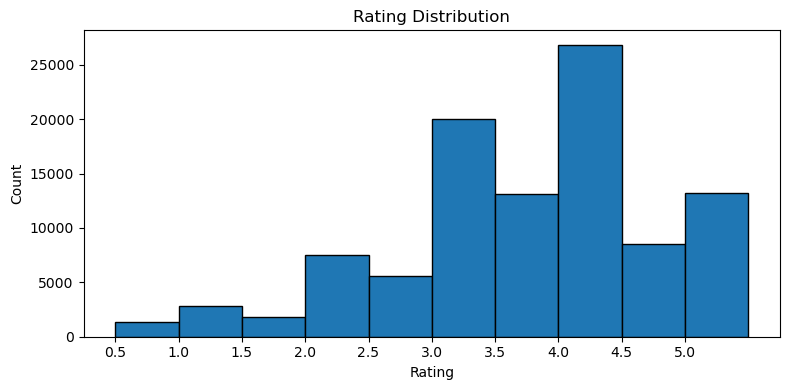

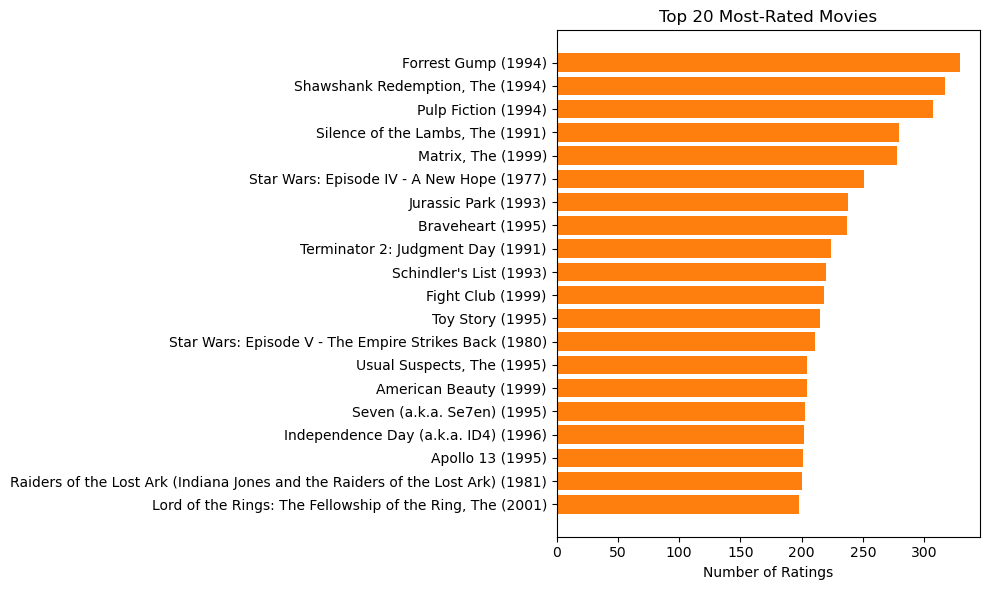

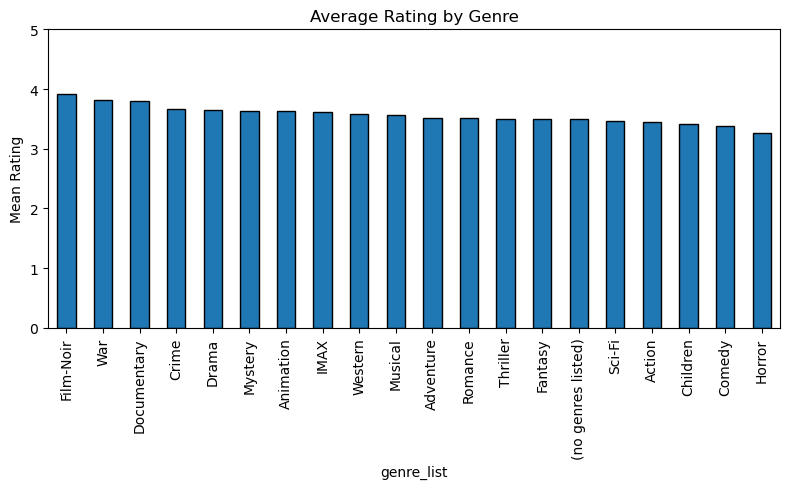

In [2]:
import matplotlib.pyplot as plt

# ——— 1) Rating Distribution ———
plt.figure(figsize=(8,4))
plt.hist(ratings['rating'], bins=[0.5,1,1.5,2,2.5,3,3.5,4,4.5,5,5.5], edgecolor='k')
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks([0.5,1,1.5,2,2.5,3,3.5,4,4.5,5])
plt.tight_layout()
plt.show()


# ——— 2) Most-Rated Movies ———
# count ratings per movie, join to titles, pick top 20
cnts = ratings.groupby('movieId').size().rename('count')
top20 = (cnts
         .sort_values(ascending=False)
         .head(20)
         .reset_index()
         .merge(movies[['movieId','title']], on='movieId'))

plt.figure(figsize=(10,6))
plt.barh(top20['title'][::-1], top20['count'][::-1], color='C1')
plt.title("Top 20 Most-Rated Movies")
plt.xlabel("Number of Ratings")
plt.tight_layout()
plt.show()


# ——— 3) Average Rating per Genre ———
# explode genres, compute avg
# first split genre strings into lists
movies['genre_list'] = movies['genres'].str.split('|')

# explode so each row is one movie-genre pair
mg = movies[['movieId','genre_list']].explode('genre_list')

# merge with ratings, compute mean rating per genre
rg = (ratings[['movieId','rating']]
      .merge(mg, on='movieId'))
avg_by_genre = rg.groupby('genre_list')['rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_by_genre.plot(kind='bar', edgecolor='k')
plt.title("Average Rating by Genre")
plt.ylabel("Mean Rating")
plt.ylim(0,5)
plt.tight_layout()
plt.show()


### Analysis of data visualization

1. Rating distribution: users tend to rate movies on the “positive” side, with a peak around ~4.0.

--> when we train a model, predicting a 4.0 or 4.5 is “safer” (since that covers many data points).
--> There are relatively few very low ratings (<2.0), so a recommender might struggle to learn what truly unpopular movies look like.

2. Top 20 Most-Rated Movies

--> Any naïve “popularity‐based” recommender (e.g., “always recommend Shawshank first”) would get reasonably high coverage/accuracy for many users, but it won’t be personalized.

--> If you use a popularity baseline (Non-Personalized), these top few films will dominate your “Top N,” so the overall system’s “precision/recall” on a popularity-only approach may look deceptively good—because most users have rated these same blockbuster films.

--> You’ll need to measure how much improvement a CF or CB method gives you beyond this “popularity” baseline.

3. Average Rating by Genre

--> Film-Noir, War, and Documentary have the highest mean ratings

--> might normalize by each genre’s “genre bias.” if building a content-based recommender

## Train/test split

In [3]:
from sklearn.model_selection import train_test_split

train_ratings, test_ratings = train_test_split(
    ratings,
    test_size=0.20,
    random_state=42,
    stratify=ratings['userId']  # stratify ensures each user’s ratings are split proportionally
)

print("Train shape:", train_ratings.shape)
print("Test shape: ", test_ratings.shape)

# Quick sanity check: ensure no user is missing entirely from train or test
train_users = set(train_ratings['userId'].unique())
test_users  = set(test_ratings['userId'].unique())
print("Users in train but not in test:", train_users - test_users)
print("Users in test but not in train:", test_users  - train_users)

# (Ideally, both sets above should be empty, meaning every user appears in both splits.)

# — Optional: check movie coverage in each split —
train_movies = set(train_ratings['movieId'].unique())
test_movies  = set(test_ratings['movieId'].unique())
print("Movies in train but not in test:", len(train_movies - test_movies))
print("Movies in test but not in train:", len(test_movies  - train_movies))

Train shape: (80668, 4)
Test shape:  (20168, 4)
Users in train but not in test: set()
Users in test but not in train: set()
Movies in train but not in test: 4604
Movies in test but not in train: 747


In [4]:
# 1) Find all movieIds that appear only in test but not in train:
train_movie_ids = set(train_ratings['movieId'].unique())
test_movie_ids  = set(test_ratings['movieId'].unique())

movies_only_in_test = test_movie_ids - train_movie_ids
print(f"Found {len(movies_only_in_test)} movies that are only in test and not yet in train.")

# 2) Pull all rows from test_ratings where movieId is in 'movies_only_in_test'
mask_test_only = test_ratings['movieId'].isin(movies_only_in_test)
to_move_back   = test_ratings[mask_test_only].copy()

# 3) Remove those rows from test_ratings, and append them to train_ratings:
test_ratings = test_ratings[~mask_test_only].copy()
train_ratings = pd.concat([train_ratings, to_move_back], ignore_index=True)

# 4) Double‐check the new shapes and coverage:
print("After moving back test-only movies:")
print("  New train_shape:", train_ratings.shape)
print("  New test_shape: ", test_ratings.shape)

train_movie_ids = set(train_ratings['movieId'].unique())
test_movie_ids  = set(test_ratings['movieId'].unique())
print("Users in train but not in test:", set(train_ratings['userId'].unique()) - set(test_ratings['userId'].unique()))
print("Users in test but not in train:", set(test_ratings['userId'].unique()) - set(train_ratings['userId'].unique()))
print("Movies in train but not in test:", len(train_movie_ids - test_movie_ids))
print("Movies in test but not in train:", len(test_movie_ids  - train_movie_ids))

Found 747 movies that are only in test and not yet in train.
After moving back test-only movies:
  New train_shape: (81469, 4)
  New test_shape:  (19367, 4)
Users in train but not in test: set()
Users in test but not in train: set()
Movies in train but not in test: 5351
Movies in test but not in train: 0


## Implement Recommender Models

### A. Non-Personalised

In [16]:
import numpy as np 
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors

# ------------------------------------------------------------------------------
# 1) NON‐PERSONALIZED BASELINES
# ------------------------------------------------------------------------------

# 1.a)  Global average predictor
#
#       Predict every rating as the overall mean rating computed on the training set.
#       Then compute RMSE versus test set.

global_mean = train_ratings['rating'].mean()
test_preds_global = np.full(shape=len(test_ratings), fill_value=global_mean)
rmse_global = np.sqrt(mean_squared_error(test_ratings['rating'], test_preds_global))
print(f"1.a) Global‐Mean RMSE = {rmse_global:.4f}")

# 1.b)  Per‐movie average predictor (“Most‐Popular”)
#
#       - Compute, on train, the average rating for each movieId.
#       - At test time, if the movie appears in train, predict its train‐average;
#         otherwise (should not happen, but just in case), fall back to global_mean.

movie_avg = train_ratings.groupby('movieId')['rating'].mean().to_dict()
def predict_movie_avg(row):
    mid = row['movieId']
    return movie_avg[mid] if mid in movie_avg else global_mean

test_preds_movie_avg = test_ratings.apply(predict_movie_avg, axis=1).values
rmse_movie_avg = np.sqrt(mean_squared_error(test_ratings['rating'], test_preds_movie_avg))
print(f"non-personlized Per‐Movie‐Avg RMSE = {rmse_movie_avg:.4f}")

#   To see it as a “top‐N” recommender, you can simply sort movies by train_ratings.count():
#   but we already plotted “most‐rated” above. That rank ≈ popularity ranking.

1.a) Global‐Mean RMSE = 1.0332
non-personlized Per‐Movie‐Avg RMSE = 0.9675


### B.  User‐based Collaborative Filtering

In [18]:
from sklearn.metrics.pairwise import cosine_similarity

# 2.1) Build user‐index / movie‐index maps on the *training* set:
unique_train_user_ids  = sorted(train_ratings['userId'].unique())
unique_train_movie_ids = sorted(train_ratings['movieId'].unique())

user_to_idx  = { uid: i for i, uid in enumerate(unique_train_user_ids) }
movie_to_idx = { mid: i for i, mid in enumerate(unique_train_movie_ids) }

n_users  = len(unique_train_user_ids)
n_movies = len(unique_train_movie_ids)

# 2.2) Build a (n_users × n_movies) sparse rating matrix for training:
#      We will store it as a list of dicts: user_ratings[u_idx] = { m_idx: rating, ... }
user_ratings = [dict() for _ in range(n_users)]
for _, row in train_ratings.iterrows():
    uidx = user_to_idx[row['userId']]
    midx = movie_to_idx[row['movieId']]
    user_ratings[uidx][midx] = row['rating']

# 2.3) Build a dense matrix just to fit NearestNeighbors (fill missing with 0)
#      (We could also build a scipy.sparse.csr_matrix, but for 100k×9k it’s okay.)
dense_train = np.zeros((n_users, n_movies), dtype=np.float32)
for uidx, ratings_dict in enumerate(user_ratings):
    for midx, r in ratings_dict.items():
        dense_train[uidx, midx] = r

# 2.4) Fit k‐NN on “dense_train” with cosine similarity:
#      We will pre‐compute neighbors for every user so we can reuse them at predict time.
k_u = 30
knn_user = NearestNeighbors(n_neighbors=k_u, metric='cosine', algorithm='brute').fit(dense_train)

# 2.5) For every user in train, retrieve its k_u nearest neighbor indices + distances:
distances, neighbor_idxs = knn_user.kneighbors(dense_train, return_distance=True)
#    distances[u, :]    = [ dist(u, neighbor[0]), dist(u, neighbor[1]), … ]  
#                       where dist = cosine‐distance = 1 − cosine‐similarity
#    neighbor_idxs[u, :] = [ index‐of‐first‐NN, index‐of‐second‐NN, … ]

#    We prefer cosine‐similarity (in [0..1]) instead of “distance”,
#    so we convert:  sim(u,v) = 1 − distance(u,v).
#
user_sim_matrix = 1.0 - distances  # shape = (n_users, k_u)

# 2.6) To predict user u’s rating on movie i:
#
#       – Find the row‐index of u:   uidx = user_to_idx[u]
#       – Look up all neighbors:    neighbors = neighbor_idxs[uidx]
#       – Look up similarity weights:  sims = user_sim_matrix[uidx]
#       – Among those k_u neighbors, keep only those who have rated i.
#       – Finally do:   sum( sim[v] * rating[v,i] ) / sum( sim[v] )
#
#    We should also guard against “no neighbors rated that item,” in which case
#    we fall back to either the user’s mean rating or the global mean.  Here we’ll
#    fall back to the average‐per‐movie predictor we already computed above.

# ─────────────────────────────────────────────────────────────────────
#  Wrap your User-CF prediction code into a single function
# ─────────────────────────────────────────────────────────────────────

def predict_rating_usercf(user_id, movie_id):
    """
    Given a (user_id, movie_id) pair, return the User-CF predicted rating.
    This re-uses exactly the same logic you had in `predict_user_cf(...)`,
    but takes (u, m) as direct arguments instead of a DataFrame row.
    """
    # 1) Look up the training‐indexed row/column for this user and this movie:
    uidx = user_to_idx.get(user_id, None)
    midx = movie_to_idx.get(movie_id, None)

    # 2) If either the user or the movie never appeared in your TRAINING set,
    #    we fall back to global_mean (or per‐movie average if you prefer):
    if (uidx is None) or (midx is None):
        # e.g. fall back to the global average rating
        return global_mean

    # 3) Get the k_u nearest neighbors (their row-indices) and their similarities:
    nbrs = neighbor_idxs[uidx]       # array of length k_u: neighbor indices
    sims = user_sim_matrix[uidx]     # array of length k_u: cosine similarities

    # 4) Accumulate weighted sum only over neighbors who actually rated this movie:
    weighted_sum = 0.0
    sim_sum      = 0.0
    for j, v_idx in enumerate(nbrs):
        # check if neighbor `v_idx` rated THIS movie (column midx)
        if midx in user_ratings[v_idx]:
            r_v_m = user_ratings[v_idx][midx]   # neighbor’s rating on movie m
            sim_v = sims[j]                     # similarity(u, v_idx)
            weighted_sum += sim_v * r_v_m
            sim_sum      += sim_v

    if sim_sum > 1e-6:
        # ordinary weighted average of neighbors’ ratings
        return weighted_sum / sim_sum
    else:
        # “Cold‐start” fallback: no neighbor of u rated this movie
        # You can choose per‐movie average or global mean here. For example:
        return movie_avg.get(movie_id, global_mean)


# 2.7) Make predictions on the test set and compute RMSE:
test_preds_ubcf = test_ratings.apply(predict_user_cf, axis=1).values
rmse_ubcf = np.sqrt(mean_squared_error(test_ratings['rating'], test_preds_ubcf))
print(f"2) User‐based CF (k_u={k_u}) RMSE = {rmse_ubcf:.4f}")

# 2.8) Suppose you want Top‐10 recommendations for a single test user, say userId = 42:
u_test = 42
if u_test not in user_to_idx:
    print(f">>> User {u_test} did not appear in train, cannot recommend.")
else:
    uidx = user_to_idx[u_test]
    # Find all movies that u_test has _not_ rated yet (in train):
    rated_by_train = set(train_ratings[train_ratings['userId']==u_test]['movieId'])
    all_movies_train = set(unique_train_movie_ids)

    # Candidate items = movies_train − rated_by_train
    candidates = list(all_movies_train - rated_by_train)

    # For each candidate, predict rating:
    preds = []
    for m in candidates:
        midx = movie_to_idx[m]
        # Re‐use predict_user_cf logic but override the row‐based interface:
        # (we know uidx and midx, so manually compute same loop)
        nbrs = neighbor_idxs[uidx]
        sims = user_sim_matrix[uidx]
        w_sum, s_sum = 0.0, 0.0
        for j, v_idx in enumerate(nbrs):
            if midx in user_ratings[v_idx]:
                r_vm = user_ratings[v_idx][midx]
                sim_v = sims[j]
                w_sum += sim_v * r_vm
                s_sum += sim_v
        if s_sum > 1e-6:
            pred_r = w_sum / s_sum
        else:
            pred_r = movie_avg.get(m, global_mean)
        preds.append((m, pred_r))

    # Sort by descending predicted rating and show top‐10:
    top10 = sorted(preds, key=lambda x: x[1], reverse=True)[:10]
    print(f"\nTop‐10 recommendations for user {u_test} (predicted rating):")
    for (m, rhat) in top10:
        title = movies.loc[movies['movieId']==m, 'title'].values[0]
        print(f"   • {title:40s} → {rhat:.3f}")

2) User‐based CF (k_u=30) RMSE = 1.0057

Top‐10 recommendations for user 42 (predicted rating):
   • Saving Santa (2013)                      → 5.000
   • Lamerica (1994)                          → 5.000
   • Wings, Legs and Tails (1986)             → 5.000
   • Heidi Fleiss: Hollywood Madam (1995)     → 5.000
   • Ivan's Childhood (a.k.a. My Name is Ivan) (Ivanovo detstvo) (1962) → 5.000
   • Awfully Big Adventure, An (1995)         → 5.000
   • What Men Talk About (2010)               → 5.000
   • Party Girl (1995)                        → 5.000
   • Eat Drink Man Woman (Yin shi nan nu) (1994) → 5.000
   • Hoop Dreams (1994)                       → 5.000


### C. Item-Based Filtering

In [7]:
# 3.1) Build a movie_ratings list of dicts: movie_ratings[i_idx] = { u_idx: rating, … }
movie_ratings = [dict() for _ in range(n_movies)]
for _, row in train_ratings.iterrows():
    uidx = user_to_idx[row['userId']]
    midx = movie_to_idx[row['movieId']]
    movie_ratings[midx][uidx] = row['rating']

# 3.2) Build a dense “item × user” NumPy array for kNN:
dense_items = np.zeros((n_movies, n_users), dtype=np.float32)
for midx, udict in enumerate(movie_ratings):
    for uidx, r in udict.items():
        dense_items[midx, uidx] = r

# 3.3) Fit k‐NN on “dense_items” with cosine metric:
k_i = 30
knn_item = NearestNeighbors(n_neighbors=k_i, metric='cosine', algorithm='brute').fit(dense_items)

dist_i, neighbor_item_idxs = knn_item.kneighbors(dense_items, return_distance=True)
item_sim_matrix = 1.0 - dist_i  # item‐item cosine similarities

# 3.4) Define a predict‐by‐item‐CF function:
def predict_item_cf(row):
    u       = row['userId']
    m       = row['movieId']
    uidx    = user_to_idx.get(u, None)
    midx    = movie_to_idx.get(m, None)

    if (uidx is None) or (midx is None):
        return global_mean

    similar_items = neighbor_item_idxs[midx]   # array of k_i similar‐item indices
    sims_i        = item_sim_matrix[midx]      # array of k_i item–item sims

    w_sum, s_sum = 0.0, 0.0
    for j, i2_idx in enumerate(similar_items):
        # Did user u rate item i2_idx?  Check movie_ratings[i2_idx] for key uidx
        if uidx in movie_ratings[i2_idx]:
            r_u_i2 = movie_ratings[i2_idx][uidx]
            sim_i2 = sims_i[j]
            w_sum += sim_i2 * r_u_i2
            s_sum += sim_i2

    if s_sum > 1e-6:
        return w_sum / s_sum
    else:
        return movie_avg.get(m, global_mean)

# 3.5) Predict on the test set, compute RMSE:
test_preds_ibcf = test_ratings.apply(predict_item_cf, axis=1).values
rmse_ibcf = np.sqrt(mean_squared_error(test_ratings['rating'], test_preds_ibcf))
print(f"\n3) Item‐based CF (k_i={k_i}) RMSE = {rmse_ibcf:.4f}")

# 3.6) Top‐10 for a single user (e.g. u_test = 42):
u_test = 42
if u_test not in user_to_idx:
    print(f">>> User {u_test} did not appear in train, cannot recommend.")
else:
    uidx = user_to_idx[u_test]
    rated_by_train = set(train_ratings[train_ratings['userId']==u_test]['movieId'])
    all_movies_train = set(unique_train_movie_ids)
    candidates = list(all_movies_train - rated_by_train)

    preds = []
    for m in candidates:
        midx = movie_to_idx[m]
        similar_items = neighbor_item_idxs[midx]
        sims_i        = item_sim_matrix[midx]
        w_sum, s_sum  = 0.0, 0.0
        for j, i2_idx in enumerate(similar_items):
            if uidx in movie_ratings[i2_idx]:
                r_u_i2 = movie_ratings[i2_idx][uidx]
                sim_i2 = sims_i[j]
                w_sum += sim_i2 * r_u_i2
                s_sum += sim_i2
        if s_sum > 1e-6:
            pred_r = w_sum / s_sum
        else:
            pred_r = movie_avg.get(m, global_mean)
        preds.append((m, pred_r))

    top10 = sorted(preds, key=lambda x: x[1], reverse=True)[:10]
    print(f"\nTop‐10 ITEM‐CF recommendations for user {u_test}:")
    for (m, rhat) in top10:
        title = movies.loc[movies['movieId']==m, 'title'].values[0]
        print(f"   • {title:40s} → {rhat:.3f}")


3) Item‐based CF (k_i=30) RMSE = 0.9458

Top‐10 ITEM‐CF recommendations for user 42:
   • Saving Santa (2013)                      → 5.000
   • Lamerica (1994)                          → 5.000
   • Lawnmower Man 2: Beyond Cyberspace (1996) → 5.000
   • Wings, Legs and Tails (1986)             → 5.000
   • Heidi Fleiss: Hollywood Madam (1995)     → 5.000
   • Ivan's Childhood (a.k.a. My Name is Ivan) (Ivanovo detstvo) (1962) → 5.000
   • What Men Talk About (2010)               → 5.000
   • Palindromes (2004)                       → 5.000
   • Live Nude Girls (1995)                   → 5.000
   • In the Realm of the Senses (Ai no corrida) (1976) → 5.000


### D. Content-Based Filtering

Goal: Build a “profile” for each user in terms of film‐features, then score each unseen movie by its cosine‐similarity to the user’s preference‐vector.

In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error

#   Assume you have already loaded:
#     movies:    a DataFrame with columns [movieId, title, genres], 
#                where genres is a pipe‐separated string (e.g. "Comedy|Romance")
#     train_ratings, test_ratings: DataFrames each with columns [userId, movieId, rating]

# 1a) Collect all unique genres from the "genres" column:
unique_genres = set()
for g in movies['genres']:
    for tag in g.split('|'):
        unique_genres.add(tag)
unique_genres = sorted(unique_genres)

# 1b) Create one‐hot genre columns on `movies`:
for tag in unique_genres:
    colname = f"is_{tag}"
    # assign 1 if that genre appears in this movie's pipe‐list, else 0
    movies[colname] = movies['genres'].apply(lambda row: 1 if tag in row.split('|') else 0)

genre_cols = [f"is_{tag}" for tag in unique_genres]

# 1c) Build a mapping: movieId → its row index in `movies` DataFrame
#     (we will use .values so that we can index a NumPy matrix by integer row)
movie_ids = movies['movieId'].values
movieid_to_index = { mid: i for i, mid in enumerate(movie_ids) }

# 1d) Extract the one‐hot matrix as a NumPy array of dtype float
#     shape = (n_movies, n_genres)
movie_feature_matrix = movies[genre_cols].values.astype(float)

from collections import defaultdict

# 2a) Gather the set of all unique userIds in the training set:
all_user_ids = np.sort(train_ratings['userId'].unique())

# 2b) Create a dictionary: raw_userId → zero‐based row index
user_index = { uid: idx for idx, uid in enumerate(all_user_ids) }

# 2c) Decide how many users and features:
n_users   = len(all_user_ids)
n_genres  = len(genre_cols)

# 2d) Prepare two arrays of shape (n_users, n_genres) and (n_users,)
#     user_pref_matrix[u_row] will hold the accumulated/normalized genre vector for user #u_row.
user_pref_matrix = np.zeros((n_users, n_genres), dtype=float)
user_norm        = np.zeros(n_users, dtype=float)

# 2e) Group all (movieId, rating) by raw userId:
user_ratings = defaultdict(list)
for _, row in train_ratings.iterrows():
    u_raw = int(row['userId'])
    m_raw = int(row['movieId'])
    r     = float(row['rating'])
    user_ratings[u_raw].append((m_raw, r))

# 2f) Now iterate through each raw user, accumulate a weighted sum of genre‐vectors:
for u_raw, rated_list in user_ratings.items():
    u_row        = user_index[u_raw]      # convert raw userId → 0‐based row
    weighted_vec = np.zeros(n_genres, dtype=float)
    weight_sum   = 0.0

    for (m_raw, r) in rated_list:
        if m_raw in movieid_to_index:
            m_row       = movieid_to_index[m_raw]
            feature_vec = movie_feature_matrix[m_row]  # length = n_genres
            weighted_vec += r * feature_vec
            weight_sum   += r
        # else: if the movie was not in the training genre matrix (unlikely), skip

    if weight_sum > 0:
        # Optionally normalize each user‐vector so it ends up unit‐length.
        # We do two steps: first divide by total rating sum, then compute actual vector norm.
        user_pref_matrix[u_row] = weighted_vec / weight_sum
        norm_val = np.linalg.norm(user_pref_matrix[u_row])
        if norm_val > 0:
            user_pref_matrix[u_row] /= norm_val
            user_norm[u_row] = 1.0   # If desired, record norm=1.0 for all non‐zero rows
        else:
            # If it collapsed to zeros (for some reason), give it a tiny norm so we never divide by zero:
            user_pref_matrix[u_row] = np.zeros(n_genres)
            user_norm[u_row]       = 1e-6
    else:
        # This user never had any training ratings (should not usually happen in ML-100k).
        user_pref_matrix[u_row] = np.zeros(n_genres)
        user_norm[u_row]        = 1e-6

test_preds_cb = []

for _, row in test_ratings.iterrows():
    u_raw = int(row['userId'])
    m_raw = int(row['movieId'])
    true_rating = float(row['rating'])

    # 3a) Convert raw ID → row in our matrices (if possible)
    if (u_raw in user_index) and (m_raw in movieid_to_index):
        u_row = user_index[u_raw]
        m_row = movieid_to_index[m_raw]

        uv = user_pref_matrix[u_row]            # length = n_genres
        mv = movie_feature_matrix[m_row]        # length = n_genres

        un = user_norm[u_row] if user_norm[u_row] != 0 else 1e-6
        mn = np.linalg.norm(mv) if np.linalg.norm(mv) != 0 else 1e-6

        # raw cosine in [−1 .. +1]
        raw_cosine = np.dot(uv, mv) / (un * mn)

        # Because these genre vectors are 0/1, uv and mv are non‐negative,
        # raw_cosine should actually lie in [0 .. 1]. But just in case, we clip:
        clipped = np.clip(raw_cosine, 0.0, 1.0)

        # Now linearly rescale from [0 .. 1] → [1 .. 5]:
        pred_rating = 1.0 + 4.0 * clipped

    else:
        # If we somehow see a test row where (user or movie) never appeared in train,
        # fall back to the global training‐mean. (This shouldn’t usually happen if you
        # moved all “test‐only” rows into train first, but we code it defensively.)
        pred_rating = train_ratings['rating'].mean()

    test_preds_cb.append(pred_rating)

test_preds_cb = np.array(test_preds_cb)
rmse_cb = np.sqrt(mean_squared_error(test_ratings['rating'], test_preds_cb))
print(f"4) Content‐Based CF RMSE = {rmse_cb:.4f}")

# Suppose we want to see Top‐10 for user 42 (raw ID = 42):
u_raw = 42

# 4a) Find all the movies that user 42 has already rated in TRAIN. We don't recommend those.
seen_by_u = { m for (m, _) in user_ratings[u_raw] }

# 4b) Build the set of *all* movieIds that appear in TRAIN
all_movies_train = set(train_ratings['movieId'].unique())

# 4c) Form the “unseen” set = all_movies_train – seen_by_u
unseen = sorted(list(all_movies_train - seen_by_u))

# 4d) For each candidate movie in “unseen”, compute its cosine with user‐42’s profile:
u_row = user_index[u_raw]
uv    = user_pref_matrix[u_row]
un    = user_norm[u_row] if user_norm[u_row] != 0 else 1e-6

cand_scores = []
for m_raw in unseen:
    m_row = movieid_to_index[m_raw]
    mv    = movie_feature_matrix[m_row]
    mn    = np.linalg.norm(mv) if np.linalg.norm(mv) != 0 else 1e-6

    raw_cosine = np.dot(uv, mv) / (un * mn)
    clipped   = np.clip(raw_cosine, 0.0, 1.0)
    score     = 1.0 + 4.0 * clipped
    cand_scores.append( (m_raw, score) )

# 4e) Sort descending and take top‐10:
cand_scores.sort(key=lambda x: x[1], reverse=True)
top10 = cand_scores[:10]

print(f"Top‐10 Content‐Based recs for user {u_raw}:")
for (m_raw, scr) in top10:
    title = movies.loc[movies['movieId']==m_raw, 'title'].values[0]
    print(f"  • {title}  → {scr:.3f}")


4) Content‐Based CF RMSE = 1.2465
Top‐10 Content‐Based recs for user 42:
  • Stunt Man, The (1980)  → 4.648
  • Hunting Party, The (2007)  → 4.519
  • Money Train (1995)  → 4.515
  • Bad Boys (1995)  → 4.515
  • Metro (1997)  → 4.515
  • Another 48 Hrs. (1990)  → 4.515
  • Wasabi (2001)  → 4.515
  • Last Boy Scout, The (1991)  → 4.515
  • Protector, The (1985)  → 4.510
  • Bronson (2009)  → 4.510


### E. Matrix Factorization (SVD)
 train a low‐rank factorization of the user–movie rating matrix (e.g. using surprise.SVD or scikit‐surprise).

In [9]:
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

# --------------------------------------------------
# Step 0:  (Assume train_ratings / test_ratings already exist)
# train_ratings and test_ratings must be pandas DataFrames 
# with columns ['userId', 'movieId', 'rating'].
#
# We'll also assume userId and movieId are integer‐valued,
# and that any movie (or user) appearing in test also appears
# at least once in train. (You already handled “test‐only movies”
# by moving them back to train.)
# --------------------------------------------------

# 1) Collect all unique userId / movieId pairs in the TRAIN set only:
all_user_ids  = np.sort(train_ratings['userId'].unique())
all_movie_ids = np.sort(train_ratings['movieId'].unique())

# 2) Build dictionaries to map raw IDs → dense indices (0‐based):
user_to_row  = { uid: i for i, uid in enumerate(all_user_ids) }
movie_to_col = { mid: j for j, mid in enumerate(all_movie_ids) }

n_users  = len(all_user_ids)
n_movies = len(all_movie_ids)

# 3) Build three parallel arrays for the CSR constructor:
row_idxs = []
col_idxs = []
data     = []

for _, row in train_ratings.iterrows():
    u_raw = int(row['userId'])
    m_raw = int(row['movieId'])
    r     = float(row['rating'])
    # Map raw→row/col
    u_row = user_to_row[u_raw]
    m_col = movie_to_col[m_raw]
    row_idxs.append(u_row)
    col_idxs.append(m_col)
    data.append(r)

# 4) Build a sparse (user × movie) “raw ratings” matrix:
rating_matrix = csr_matrix((data, (row_idxs, col_idxs)), shape=(n_users, n_movies))
print("Sparse rating matrix:", rating_matrix.shape, "with", rating_matrix.nnz, "filled entries.")

# --------------------------------------------------
# Step 5:  Mean‐center each row (i.e. subtract out each user’s average),
# so that the SVD sees a zero‐mean rating for each user.
# --------------------------------------------------

# 5a) Compute “row sums” and “row counts” (number of nonzero elements per user):
#     rating_matrix.sum(axis=1) gives a (n_users × 1) dense matrix of the sum of ratings in each row.
row_sums   = np.array(rating_matrix.sum(axis=1)).flatten()       # shape = (n_users,)
row_counts = np.diff(rating_matrix.indptr)                        # shape = (n_users,)

# 5b) For users who have no ratings (count=0), just set their mean to zero to avoid divide‐by‐zero.
user_row_mean = np.zeros(n_users, dtype=float)
nonzero_users = row_counts > 0
user_row_mean[nonzero_users] = (row_sums[nonzero_users] / row_counts[nonzero_users])

# 5c) Now create a “mean‐centered” sparse matrix by subtracting each user’s row‐mean from that user’s nonzero entries.
#     SciPy allows us to “each nonzero in row i minus user_row_mean[i]” via the CSR data/indices structure.
#
#     We will copy the sparse matrix’s .data into a new array, subtract out the row mean, 
#     and then build a new CSR with identical sparsity but mean‐centered values.
#
#     Let’s do it in place (on a copy of rating_matrix) to avoid confusion:

row_meaned_data = rating_matrix.data.copy()
rowptr = rating_matrix.indptr
colidx = rating_matrix.indices  # not actually needed for the math, but we need .indptr

# For each nonzero entry at index p in row i, the raw rating is rating_matrix.data[p].  We want
#   rating_matrix.data[p] ← rating_matrix.data[p] − user_row_mean[i],  
# where i is the row that ’p­th’ data belongs to.  We can look up row i by finding which rowptr‐bin
# contains p.  SciPy already stores rowptr properly, so we can do a two‐pointer approach.

# A simple for‐loop over users:
for u_row in range(n_users):
    start = rowptr[u_row]
    stop  = rowptr[u_row+1]
    if start < stop:  # i.e. this user has some nonzero entries
        row_meaned_data[start:stop] -= user_row_mean[u_row]

# Finally, construct a new CSR that uses the same index structure but has mean‐centered data:
rating_matrix_centered = csr_matrix((row_meaned_data, colidx, rowptr), shape=(n_users, n_movies))

# At this point, rating_matrix_centered[u_row, m_col] = (original rating − user_row_mean[u_row]).
print("Built mean‐centered rating matrix with same shape:", rating_matrix_centered.shape)
# --------------------------------------------------
# Step 6:  Run TruncatedSVD on the *mean‐centered* matrix
# --------------------------------------------------

k = 20   # number of latent factors (you can experiment with 10, 20, 50, etc.)
svd = TruncatedSVD(n_components=k, n_iter=15, random_state=42)
svd.fit(rating_matrix_centered)

#   - svd.components_.shape == (k, n_movies)  
#   - svd.singular_values_.shape == (k,)

# 6a) Compute each user’s k‐dimensional latent vector:
#     rating_matrix_centered is (n_users, n_movies),  components_.T is (n_movies, k),
#     so the product is (n_users, k).  Call that “user_factors_raw.”
user_factors_raw = rating_matrix_centered.dot(svd.components_.T)  # shape = (n_users, k)

# 6b) Now divide each column of user_factors_raw by the corresponding singular value:
Sigma_inv = np.diag(1.0 / svd.singular_values_)  # shape = (k, k)
user_factors = user_factors_raw.dot(Sigma_inv)   # final shape = (n_users, k)

# 6c) Compute the movie factors:  components_.shape = (k, n_movies).
#     We know components_ ≃ Σ^(‐1) * V^T.  Therefore V^T ≃ Σ * components_ ⇒ V ≃ components_.T * Σ.
movie_factors = svd.components_.T * svd.singular_values_   # broadcasting (n_movies, k) * (k,) → (n_movies, k)

print("user_factors shape:", user_factors.shape)   # should be (n_users, k)
print("movie_factors shape:", movie_factors.shape) # should be (n_movies, k)

# --------------------------------------------------
# Step 7:  Predict on the TEST set.  IMPORTANT: we must “undo” the mean‐centering.
# --------------------------------------------------

test_preds_svd = []
global_mean = train_ratings['rating'].mean()

for _, row in test_ratings.iterrows():
    u_raw = int(row['userId'])
    m_raw = int(row['movieId'])
    true_r = float(row['rating'])

    if (u_raw in user_to_row) and (m_raw in movie_to_col):
        u_row = user_to_row[u_raw]
        m_col = movie_to_col[m_raw]

        # 7a) Dot‐product in the mean‐centered latent space
        pred_centered = float(user_factors[u_row].dot(movie_factors[m_col]))

        # 7b) Add back the user baseline (row mean) so that our final pred is in original rating scale.
        #     (Originally we subtracted user_row_mean[u_row], so now we add it back.)
        pred = pred_centered + user_row_mean[u_row]

        # 7c) Clip to [1..5]:
        pred = np.clip(pred, 1.0, 5.0)
    else:
        # Fall back to global mean if a user or movie never appeared in train
        pred = global_mean

    test_preds_svd.append(pred)

test_preds_svd = np.array(test_preds_svd)
rmse_svd = np.sqrt(mean_squared_error(test_ratings['rating'], test_preds_svd))
print(f"SVD (with user‐mean‐centering) RMSE = {rmse_svd:.4f}")


Sparse rating matrix: (610, 9724) with 81469 filled entries.
Built mean‐centered rating matrix with same shape: (610, 9724)
user_factors shape: (610, 20)
movie_factors shape: (9724, 20)
SVD (with user‐mean‐centering) RMSE = 0.9111


#### Add a tiny “ridge” or small regularization to SVD

lightly regularize the “factorization” by shrinking the singular values or explicitly subtracting out global/user/movie means.

In [10]:
# --------------------------------------------------
# Step 0:  (Assume train_ratings / test_ratings already exist)
# train_ratings and test_ratings must be pandas DataFrames 
# with columns ['userId', 'movieId', 'rating'].
#
# We'll also assume userId and movieId are integer‐valued,
# and that any movie (or user) appearing in test also appears
# at least once in train. (You already handled “test‐only movies”
# by moving them back to train.)
# --------------------------------------------------

# 1) Collect all unique userId / movieId pairs in the TRAIN set only:
all_user_ids  = np.sort(train_ratings['userId'].unique())
all_movie_ids = np.sort(train_ratings['movieId'].unique())

# 2) Build dictionaries to map raw IDs → dense indices (0‐based):
user_to_row  = { uid: i for i, uid in enumerate(all_user_ids) }
movie_to_col = { mid: j for j, mid in enumerate(all_movie_ids) }

n_users  = len(all_user_ids)
n_movies = len(all_movie_ids)

# 3) Build three parallel arrays for the CSR constructor:
row_idxs = []
col_idxs = []
data     = []

for _, row in train_ratings.iterrows():
    u_raw = int(row['userId'])
    m_raw = int(row['movieId'])
    r     = float(row['rating'])
    # Map raw→row/col
    u_row = user_to_row[u_raw]
    m_col = movie_to_col[m_raw]
    row_idxs.append(u_row)
    col_idxs.append(m_col)
    data.append(r)

# 4) Build a sparse (user × movie) “raw ratings” matrix:
rating_matrix = csr_matrix((data, (row_idxs, col_idxs)), shape=(n_users, n_movies))
print("Sparse rating matrix:", rating_matrix.shape, "with", rating_matrix.nnz, "filled entries.")

# ------------------------------------------------------------
# 5) Mean‐center each row:
# ------------------------------------------------------------
row_sums   = np.array(rating_matrix.sum(axis=1)).flatten()
row_counts = np.diff(rating_matrix.indptr)
user_row_mean = np.zeros_like(row_sums, dtype=float)
nonzero_users = (row_counts > 0)
user_row_mean[nonzero_users] = row_sums[nonzero_users] / row_counts[nonzero_users]

row_meaned_data = rating_matrix.data.copy()
rowptr = rating_matrix.indptr
for u_row in range(rating_matrix.shape[0]):
    start, stop = rowptr[u_row], rowptr[u_row+1]
    if start < stop:
        row_meaned_data[start:stop] -= user_row_mean[u_row]

rating_matrix_centered = csr_matrix(
    (row_meaned_data, rating_matrix.indices, rating_matrix.indptr),
    shape=rating_matrix.shape
)
print("Built mean‐centered rating matrix with same shape:", rating_matrix_centered.shape)

# ------------------------------------------------------------
# 6) Fit SVD on the *centered* matrix (not the raw one)
# ------------------------------------------------------------
k   = 20
lam = 0.1

svd = TruncatedSVD(n_components=k, n_iter=10, random_state=42)
svd.fit(rating_matrix_centered)         # ← IMPORTANT: use the centered matrix

# ------------------------------------------------------------
# 7) Shrink the singular values
# ------------------------------------------------------------
sig     = svd.singular_values_.copy()   # length = k
sig_reg = sig / np.sqrt(sig**2 + lam)   # shape = (k,)

# ------------------------------------------------------------
# 8) Recompute user factors from the *centered* matrix
# ------------------------------------------------------------
U_raw_centered = rating_matrix_centered.dot(svd.components_.T)  # (n_users, k)
sigma_reg_inv  = np.diag(1.0 / sig_reg)                         # (k, k)
user_factors_reg = U_raw_centered.dot(sigma_reg_inv)            # (n_users, k)

# ------------------------------------------------------------
# 9) Recompute movie factors from the shrunken singulars:
#     Recall: components_ = Σ⁻¹ · V^T  ⇒  V^T = Σ · components_
#     So if Σ ⇒ Σ′ (diagonal of sig_reg), then
#     movie_factors_reg = components_.T * sig_reg  (broadcasting)
# ------------------------------------------------------------
movie_factors_reg = svd.components_.T * sig_reg            # (n_movies, k)

print("user_factors_reg shape: ", user_factors_reg.shape)
print("movie_factors_reg shape:", movie_factors_reg.shape)

# ------------------------------------------------------------
# 10) Do your usual test‐set loop, using these “reg” factors
# ------------------------------------------------------------
best_rmse = 1e9
best_params = None

for k in [10, 20, 30]:
    # (re‐centering code from steps 5a–5c lived outside the loops)
    svd = TruncatedSVD(n_components=k, n_iter=10, random_state=42)
    # Fit on the mean‐centered matrix
    svd.fit(rating_matrix_centered)

    # Grab the raw singular values once per k
    sig = svd.singular_values_.copy()  # length = k
    comps = svd.components_            # shape = (k, n_movies)
    comps_T = comps.T                  # (n_movies, k)

    for lam in [0.1, 1.0, 5.0, 10.0, 20.0]:
        # 7) Shrink the singular values:
        sig_reg = sig / np.sqrt(sig**2 + lam)     # (k,)

        # 8) Build user_factors_reg from the centered matrix:
        U_raw_centered = rating_matrix_centered.dot(comps_T)  # (n_users, k)
        sigma_reg_inv = np.diag(1.0 / sig_reg)                 # (k, k)
        user_factors_reg = U_raw_centered.dot(sigma_reg_inv)   # (n_users, k)

        # 9) Build movie_factors_reg from sig_reg and comps_T:
        #    recall: V^T = Σ × (components_), so if Σ→Σ′, then 
        #    movie_factors_reg = comps_T * sig_reg
        movie_factors_reg = comps_T * sig_reg  # broadcasting (n_movies, k) * (k,) → (n_movies, k)

        # 10) Evaluate on the test set:
        test_preds = []
        for _, row in test_ratings.iterrows():
            u_raw = int(row['userId'])
            m_raw = int(row['movieId'])
            true_r = float(row['rating'])

            if (u_raw in user_to_row) and (m_raw in movie_to_col):
                u_idx = user_to_row[u_raw]
                m_idx = movie_to_col[m_raw]
                # Dot product of the regularized factors:
                pred_centered = float(user_factors_reg[u_idx].dot(movie_factors_reg[m_idx]))
                # Add back the user’s mean and clip to [1,5]:
                pred = np.clip(pred_centered + user_row_mean[u_idx], 1.0, 5.0)
            else:
                pred = train_ratings['rating'].mean()
            test_preds.append(pred)

        rmse = np.sqrt(mean_squared_error(test_ratings['rating'], np.array(test_preds)))

        # Keep track of the best (k, λ):
        if rmse < best_rmse:
            best_rmse = rmse
            best_params = (k, lam)

        print(f"   → k={k:2d}, λ={lam:5.1f}  RMSE={rmse:.4f}")

print(f"Best configuration: k={best_params[0]}, λ={best_params[1]}  with RMSE={best_rmse:.4f}")


Sparse rating matrix: (610, 9724) with 81469 filled entries.
Built mean‐centered rating matrix with same shape: (610, 9724)
user_factors_reg shape:  (610, 20)
movie_factors_reg shape: (9724, 20)
   → k=10, λ=  0.1  RMSE=0.9082
   → k=10, λ=  1.0  RMSE=0.9082
   → k=10, λ=  5.0  RMSE=0.9082
   → k=10, λ= 10.0  RMSE=0.9082
   → k=10, λ= 20.0  RMSE=0.9082
   → k=20, λ=  0.1  RMSE=0.9111
   → k=20, λ=  1.0  RMSE=0.9111
   → k=20, λ=  5.0  RMSE=0.9111
   → k=20, λ= 10.0  RMSE=0.9111
   → k=20, λ= 20.0  RMSE=0.9111
   → k=30, λ=  0.1  RMSE=0.9133
   → k=30, λ=  1.0  RMSE=0.9133
   → k=30, λ=  5.0  RMSE=0.9133
   → k=30, λ= 10.0  RMSE=0.9133
   → k=30, λ= 20.0  RMSE=0.9133
Best configuration: k=10, λ=0.1  with RMSE=0.9082


### F. Ensemble (User‐based CF + SVD + content‐based)

In [11]:
w_cf      = 0.30
w_svd     = 0.50
w_content = 0.20

assert abs(w_cf + w_svd + w_content - 1.0) < 1e-8

hybrid_preds = (w_cf    * test_preds_ubcf
                + w_svd * test_preds_svd
                + w_content * test_preds_cb)

# Optionally clip into [1, 5]:
hybrid_preds = np.clip(hybrid_preds, 1.0, 5.0)


# Compute the final RMSE of the ensemble
rmse_hybrid = np.sqrt(mean_squared_error(test_ratings["rating"], hybrid_preds))
print(f"Hybrid ensemble RMSE on test = {rmse_hybrid:.4f}")


Hybrid ensemble RMSE on test = 0.8947


In [12]:
import numpy as np
from sklearn.metrics import mean_squared_error

best_rmse = 1e9
best_weights = None

# Generate weights 0.0, 0.1, 0.2, ..., 1.0 by using np.arange
cf_values  = np.arange(0.0, 1.0 + 1e-9, 0.1)   # 0.0, 0.1, 0.2, …, 1.0
svd_values = np.arange(0.0, 1.0 + 1e-9, 0.1)

for w_cf in cf_values:
    for w_svd in svd_values:
        w_cont = 1.0 - w_cf - w_svd
        # Only keep combinations that sum exactly to 1 (up to floating‐point tolerance)
        if w_cont < -1e-8 or w_cont > 1.0 + 1e-8:
            continue

        # Now form the hybrid prediction
        preds = (
            w_cf   * test_preds_ubcf 
          + w_svd  * test_preds_svd 
          + w_cont * test_preds_cb
        )
        preds = np.clip(preds, 1.0, 5.0)

        rmse = np.sqrt(mean_squared_error(test_ratings["rating"], preds))
        if rmse < best_rmse:
            best_rmse    = rmse
            # Round weights to one decimal place if you like, or just store raw floats
            best_weights = (round(w_cf,1), round(w_svd,1), round(w_cont,1))

print("Best hybrid:", best_weights, "→ RMSE=", best_rmse)


Best hybrid: (0.3, 0.7, -0.0) → RMSE= 0.8768014698120344


### Generative AI

In [ ]:
import os
from dotenv import load_dotenv
import openai

# 1) Load your API key from .env into openai.api_key
load_dotenv()  # reads .env from the current directory
openai.api_key = os.getenv("OPENAI_API_KEY")
if openai.api_key is None:
    raise RuntimeError("Could not read OPENAI_API_KEY from .env")

# 2) A helper function that calls the v1 client:
def generate_generative_recs(
    user_id: int,
    top_movies: list[int],
    user_info: dict | None = None,
    model: str = "gpt-3.5-turbo",
) -> str:
    """
    Return a paragraph of generative recommendations for `user_id`,
    given top_movies (IDs) and optional user_info (e.g. favorite_genres, age, ...).
    This uses openai-python v1.x (mid-2025).
    """
    # (a) build a simple string like “318, 260, 1196, 2028, 527”
    movies_str = ", ".join(str(m) for m in top_movies)

    # (b) flatten optional user_info into “key = value; key2 = value2”
    user_ctx = ""
    if user_info:
        parts = []
        for k, v in user_info.items():
            parts.append(f"{k} = {v}")
        user_ctx = "User info: " + "; ".join(parts) + ".\n"
    else:
        user_ctx = ""

    # (c) system message + user message
    system_msg = {
        "role": "system",
        "content": (
            "You are a friendly movie-recommendation assistant. "
            "When given a user’s favorite movies and profile, "
            "you should output a single paragraph that: "
            "(1) suggests 2–3 new movies the user might like, "
            "(2) briefly explains why, based on their tastes."
        )
    }
    user_msg = {
        "role": "user",
        "content": (
            f"Here is the user ID: {user_id}.\n"
            f"{user_ctx}"
            f"Their top-rated movies are: {movies_str}.\n"
            "Suggest 2–3 other movies they might enjoy, "
            "and mention any obvious genre/personality matches you see."
        )
    }

    # (d) The new v1.x “chat.completions” endpoint:
    resp = openai.ChatCompletion.create(
        model=model,
        messages=[system_msg, user_msg],
        temperature=0.8,
        max_tokens=200,
    )
    # (e) Pull out the assistant’s reply
    return resp.choices[0].message.content


# 3) Example usage (run this cell to see a sample output)
if __name__ == "__main__":
    top_5_for_user_100 = [318, 260, 1196, 2028, 527]
    user_profile = {
        "favorite_genres": "Sci-Fi, Action, Mystery",
        "age": "28",
        "location": "San Francisco"
    }

    bio = generate_generative_recs(
        user_id=100,
        top_movies=top_5_for_user_100,
        user_info=user_profile,
        model="gpt-3.5-turbo",  # or “gpt-4”
    )

    print("\n— Generative Recommendation for User 100 —\n")
    print(bio)


## Evaluation

### RMSE for rating prediction accuracy.

### Precision/Recall for top-N recommendation quality.

### Optionally: F1-score, Coverage, Diversity.

Train shape: (81469, 4)
Test shape:  (19367, 4)
>>> Non‐Personalized Precision/Recall:
  Precision@5=0.0000    Recall@5=0.0000
  Precision@10=0.0003    Recall@10=0.0000
  Precision@20=0.0006    Recall@20=0.0001

>>> User‐CF (k_u=30) Precision/Recall:


NotImplementedError: Please fill in predict_rating_usercf(...) with your code.